In [5]:
import sys
!{sys.executable} -m pip install pyswarms deap keras-tcn

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/4 [future]
   ---------------------------------------- 0/4 [future]
   ---------------------------------------- 0/4 [future]
   ---------------------------------------- 0/4 [future]
   ---------------------------------------- 0/4 [future]
   ---------------------------------------- 0/4 [future]
   ---------------------------------------- 0/4 [future]
   ---------------------------------------- 0/4 [future]
   ---------------------------------------- 0/4 [future]
   ---------------------------------------- 0/4 [future]
   ---------------------------------------- 0/4 [future]
   ---------------------------------------- 0/4 [future]
   ---------------------------------------- 0/4 [future]
   ---------------------------------------- 0/4 [future]
   ---------------------------------------- 0/4 [future]
   ---------------------------------------- 0/4 [future]
   ------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.statespace.sarimax import SARIMAX

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tcn import TCN

import pyswarms as ps

from deap import base, creator, tools, algorithms
import random

np.random.seed(42)
random.seed(42)



In [7]:
data_path = Path("cleandata.csv")
if not data_path.exists():
    raise FileNotFoundError(
        "cleandata.csv was not found. Put it in the same folder as this notebook before running."
    )

df = pd.read_csv(data_path)

df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

series = df['demand_kWh']
series = series.asfreq('h')
series = series.ffill()


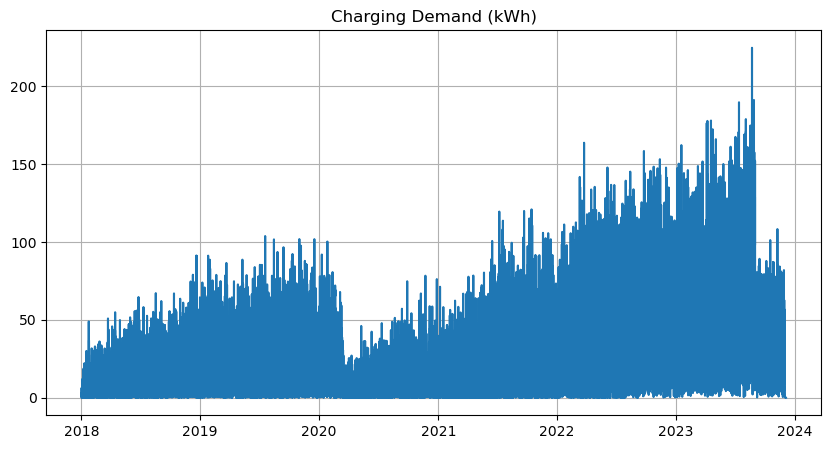

In [8]:
plt.figure(figsize=(10,5))
plt.plot(series)
plt.title("Charging Demand (kWh)")
plt.grid()
plt.show()

train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

In [9]:
sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(0,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False,
    simple_differencing=True
)

sarima_fit = sarima_model.fit(disp=False, low_memory=True)
sarima_pred = sarima_fit.forecast(steps=len(test))

In [10]:
# SCALING + SEQUENCES
scaler = MinMaxScaler()
scaled = scaler.fit_transform(series.values.reshape(-1,1))

def create_sequences(data, window=24):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 24
X, y = create_sequences(scaled, window)

X_train, X_test = X[:train_size-window], X[train_size-window:]
y_train, y_test = y[:train_size-window], y[train_size-window:]

y_test_inv = scaler.inverse_transform(y_test)

In [11]:
# TCN MODEL
def sanitize_tcn_params(filters=64, kernel_size=3, dropout=0.2):
    filters = int(np.clip(round(filters), 32, 128))
    kernel_size = int(np.clip(round(kernel_size), 2, 5))
    dropout = float(np.clip(dropout, 0.1, 0.5))
    return filters, kernel_size, dropout

def build_tcn(filters=64, kernel_size=3, dropout=0.2):
    filters, kernel_size, dropout = sanitize_tcn_params(filters, kernel_size, dropout)

    model = Sequential([
        TCN(filters, kernel_size=kernel_size, dropout_rate=dropout, return_sequences=False),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

tcn_model = build_tcn()
tcn_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1)
tcn_pred = scaler.inverse_transform(tcn_model.predict(X_test, verbose=0))


Epoch 1/10



2026-04-20 13:44:13,663 - tensorflow - WARNING - From C:\Users\ASUS TUF-Pc\AppData\Roaming\Python\Python313\site-packages\keras\src\backend\tensorflow\core.py:232: The name tf.placeholder is deprecated. Please use tf.compat.v1.placeholder instead.



1038/1038 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - loss: 0.0198 - val_loss: 0.0044
Epoch 2/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - loss: 0.0018 - val_loss: 0.0039
Epoch 3/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - loss: 0.0016 - val_loss: 0.0037
Epoch 4/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 25s 24ms/step - loss: 0.0015 - val_loss: 0.0037
Epoch 5/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - loss: 0.0015 - val_loss: 0.0044
Epoch 6/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - loss: 0.0015 - val_loss: 0.0040
Epoch 7/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - loss: 0.0014 - val_loss: 0.0038
Epoch 8/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 25s 24ms/step - loss: 0.0014 - val_loss: 0.0041
Epoch 9/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - loss: 0.0014 - val_loss: 0.0033
Epoch 10/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - loss: 0.0014 - val_loss: 0.0032


In [13]:
# PSO OPTIMIZATION
def fitness_function(params):
    errors = []
    for p in params:
        filters, kernel_size, dropout = sanitize_tcn_params(p[0], p[1], p[2])
        model = build_tcn(filters, kernel_size, dropout)
        model.fit(X_train, y_train, epochs=5, verbose=0)

        pred = scaler.inverse_transform(model.predict(X_test, verbose=0))
        error = float(np.mean((pred - y_test_inv) ** 2))
        errors.append(error)
    return np.array(errors)

bounds = (np.array([32, 2, 0.1]), np.array([128, 5, 0.5]))

optimizer = ps.single.GlobalBestPSO(
    n_particles=5,
    dimensions=3,
    options={'c1': 0.5, 'c2': 0.3, 'w': 0.9},
    bounds=bounds
)

best_cost, best_pos = optimizer.optimize(fitness_function, iters=10)

best_filters, best_kernel, best_dropout = sanitize_tcn_params(best_pos[0], best_pos[1], best_pos[2])
pso_model = build_tcn(best_filters, best_kernel, best_dropout)
pso_model.fit(X_train, y_train, epochs=20, validation_split=0.2, verbose=1)
pso_pred = scaler.inverse_transform(pso_model.predict(X_test, verbose=0))


2026-04-20 15:18:46,188 - pyswarms.single.global_best - INFO - Optimize for 10 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|████████████████████████████████████████████████████████████████|10/10, best_cost=171
2026-04-20 20:30:07,877 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 170.89077222929302, best pos: [96.52501255  4.28485885  0.19505502]


Epoch 1/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 91s 78ms/step - loss: 0.0082 - val_loss: 0.0038
Epoch 2/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 76s 73ms/step - loss: 0.0016 - val_loss: 0.0038
Epoch 3/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 81s 78ms/step - loss: 0.0015 - val_loss: 0.0034
Epoch 4/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 86s 82ms/step - loss: 0.0015 - val_loss: 0.0038
Epoch 5/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 82s 79ms/step - loss: 0.0014 - val_loss: 0.0035
Epoch 6/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 79s 76ms/step - loss: 0.0014 - val_loss: 0.0039
Epoch 7/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 79s 76ms/step - loss: 0.0014 - val_loss: 0.0032
Epoch 8/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 82s 79ms/step - loss: 0.0014 - val_loss: 0.0034
Epoch 9/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 83s 80ms/step - loss: 0.0014 - val_loss: 0.0035
Epoch 10/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 80s 77ms/step - loss: 0.0014 - val_loss: 0.0034
Epoch 11/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 77s 74ms/step - loss: 0.0014 - val_loss: 0.0038
Epoch 12

In [14]:
# GA OPTIMIZATION
if "FitnessMin" in creator.__dict__:
    del creator.FitnessMin
if "Individual" in creator.__dict__:
    del creator.Individual

creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

def clean_individual(ind):
    filters, kernel_size, dropout = sanitize_tcn_params(ind[0], ind[1], ind[2])
    ind[0], ind[1], ind[2] = filters, kernel_size, dropout
    return ind

def eval_individual(ind):
    clean_individual(ind)
    model = build_tcn(ind[0], ind[1], ind[2])
    model.fit(X_train, y_train, epochs=5, verbose=0)

    pred = scaler.inverse_transform(model.predict(X_test, verbose=0))
    return (float(np.mean((pred - y_test_inv) ** 2)),)

toolbox = base.Toolbox()
toolbox.register("attr_filters", random.randint, 32, 128)
toolbox.register("attr_kernel", random.randint, 2, 5)
toolbox.register("attr_dropout", random.uniform, 0.1, 0.5)

toolbox.register(
    "individual",
    tools.initCycle,
    creator.Individual,
    (toolbox.attr_filters, toolbox.attr_kernel, toolbox.attr_dropout),
    n=1
)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", eval_individual)

def mate_individuals(ind1, ind2):
    tools.cxBlend(ind1, ind2, alpha=0.5)
    clean_individual(ind1)
    clean_individual(ind2)
    return ind1, ind2

def mutate_individual(ind):
    ind[0] = ind[0] + random.randint(-10, 10)
    ind[1] = ind[1] + random.randint(-1, 1)
    ind[2] = ind[2] + random.uniform(-0.1, 0.1)
    clean_individual(ind)
    return (ind,)

toolbox.register("mate", mate_individuals)
toolbox.register("mutate", mutate_individual)
toolbox.register("select", tools.selTournament, tournsize=3)

pop = toolbox.population(n=5)
pop, _ = algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=5, verbose=True)

best_ind = clean_individual(tools.selBest(pop, 1)[0])

ga_model = build_tcn(best_ind[0], best_ind[1], best_ind[2])
ga_model.fit(X_train, y_train, epochs=20, validation_split=0.2, verbose=1)
ga_pred = scaler.inverse_transform(ga_model.predict(X_test, verbose=0))


gen	nevals
0  	5     
1  	2     
2  	3     
3  	4     
4  	3     
5  	5     
Epoch 1/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 119s 105ms/step - loss: 0.0065 - val_loss: 0.0033
Epoch 2/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 108s 104ms/step - loss: 0.0015 - val_loss: 0.0037
Epoch 3/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 114s 110ms/step - loss: 0.0014 - val_loss: 0.0035
Epoch 4/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 104s 100ms/step - loss: 0.0014 - val_loss: 0.0037
Epoch 5/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 107s 103ms/step - loss: 0.0014 - val_loss: 0.0031
Epoch 6/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 104s 100ms/step - loss: 0.0014 - val_loss: 0.0033
Epoch 7/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 103s 100ms/step - loss: 0.0014 - val_loss: 0.0032
Epoch 8/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 102s 98ms/step - loss: 0.0014 - val_loss: 0.0032
Epoch 9/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 105s 101ms/step - loss: 0.0014 - val_loss: 0.0035
Epoch 10/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 101s 97ms/step - loss: 0.0013 - val_loss: 0.0045
Epoc

In [15]:
def metrics(actual, pred):
    actual = np.array(actual).flatten()
    pred = np.array(pred).flatten()
    
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    
    mape = np.mean(np.abs((actual - pred) / np.where(actual==0, 1e-8, actual))) * 100
    
    smape = np.mean(
        np.abs(pred - actual) / ((np.abs(actual) + np.abs(pred)) / 2 + 1e-8)
    ) * 100
    
    r2 = r2_score(actual, pred)
    
    return mae, rmse, mape, smape, r2

In [16]:
# EVALUATION
m_sarima = metrics(test.values, sarima_pred.values)
m_tcn = metrics(y_test_inv, tcn_pred)
m_pso = metrics(y_test_inv, pso_pred)
m_ga = metrics(y_test_inv, ga_pred)

In [17]:
results_df = pd.DataFrame({
    'Model': ['SARIMA', 'TCN', 'PSO-TCN', 'GA-TCN'],
    'MAE': [m_sarima[0], m_tcn[0], m_pso[0], m_ga[0]],
    'RMSE': [m_sarima[1], m_tcn[1], m_pso[1], m_ga[1]],
    'MAPE (%)': [m_sarima[2], m_tcn[2], m_pso[2], m_ga[2]],
    'SMAPE (%)': [m_sarima[3], m_tcn[3], m_pso[3], m_ga[3]],
    'R2': [m_sarima[4], m_tcn[4], m_pso[4], m_ga[4]],
})

print("\nMODEL PERFORMANCE COMPARISON:\n")
print(results_df)


MODEL PERFORMANCE COMPARISON:

     Model        MAE       RMSE    MAPE (%)   SMAPE (%)        R2
0   SARIMA  46.005234  58.964192  100.026059  199.921230 -1.556093
1      TCN   9.511792  13.958261   40.275445   26.746033  0.856761
2  PSO-TCN  10.507666  15.590713   35.420631   30.145581  0.821297
3   GA-TCN   9.560636  14.316833   34.441748   25.002945  0.849307


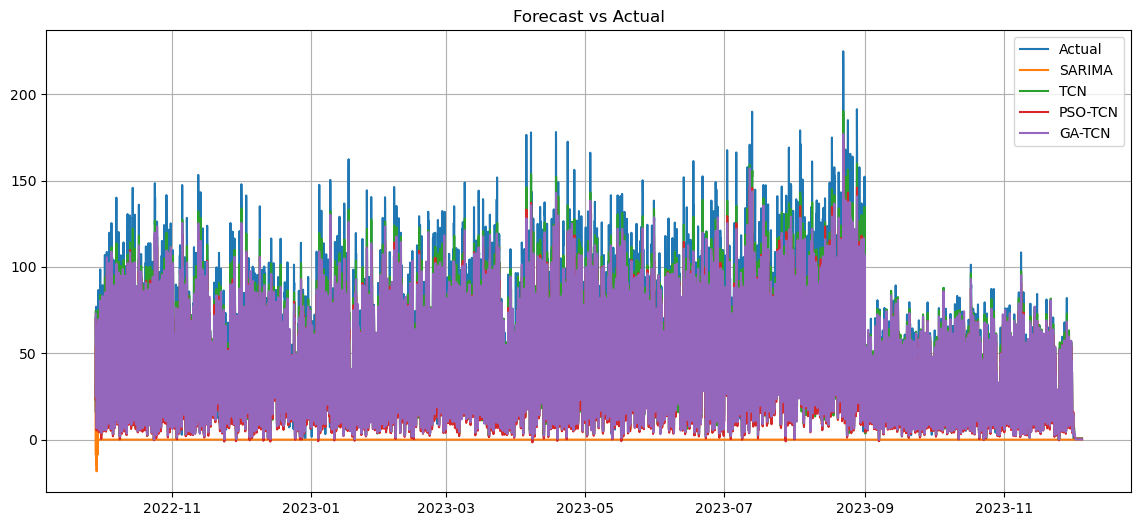

In [18]:
plt.figure(figsize=(14,6))
plt.plot(test.index, test.values, label='Actual')
plt.plot(test.index, sarima_pred.values, label='SARIMA')
plt.plot(test.index[-len(tcn_pred):], tcn_pred.flatten(), label='TCN')
plt.plot(test.index[-len(pso_pred):], pso_pred.flatten(), label='PSO-TCN')
plt.plot(test.index[-len(ga_pred):], ga_pred.flatten(), label='GA-TCN')
plt.legend()
plt.title("Forecast vs Actual")
plt.grid()
plt.show()


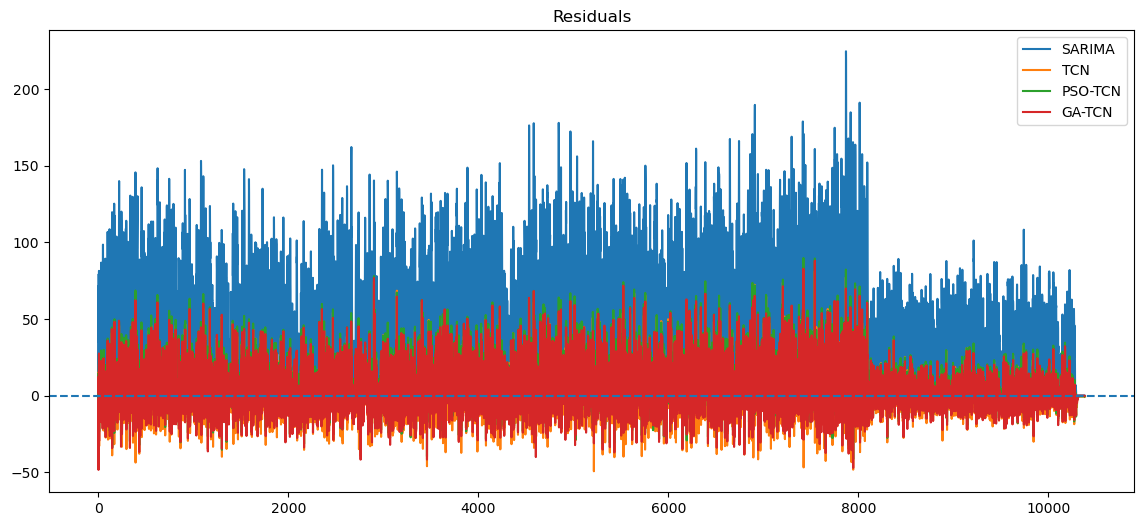

In [19]:
# Residuals
plt.figure(figsize=(14,6))
plt.plot(test.values - sarima_pred.values, label='SARIMA')
plt.plot(y_test_inv.flatten() - tcn_pred.flatten(), label='TCN')
plt.plot(y_test_inv.flatten() - pso_pred.flatten(), label='PSO-TCN')
plt.plot(y_test_inv.flatten() - ga_pred.flatten(), label='GA-TCN')
plt.axhline(0, linestyle='--')
plt.legend()
plt.title("Residuals")
plt.show()

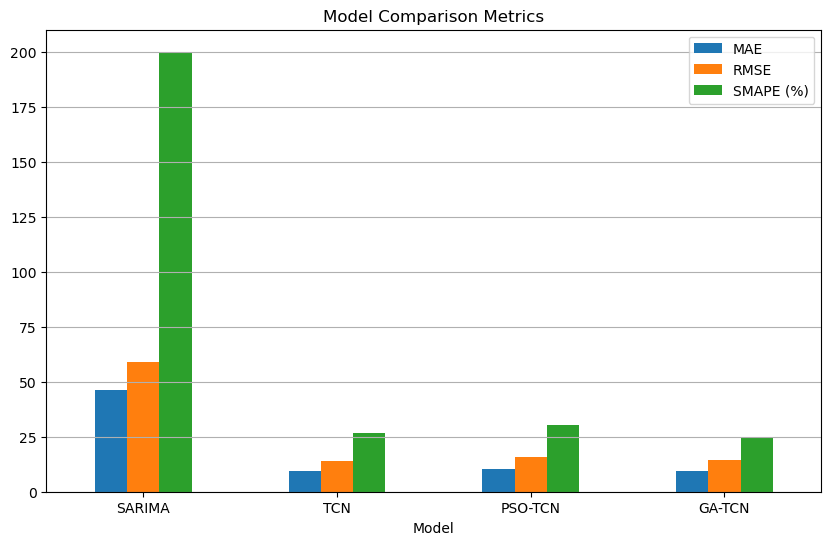

In [20]:
# Metrics comparison
results_df.set_index('Model')[['MAE','RMSE','SMAPE (%)']].plot(kind='bar', figsize=(10,6))
plt.title("Model Comparison Metrics")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()